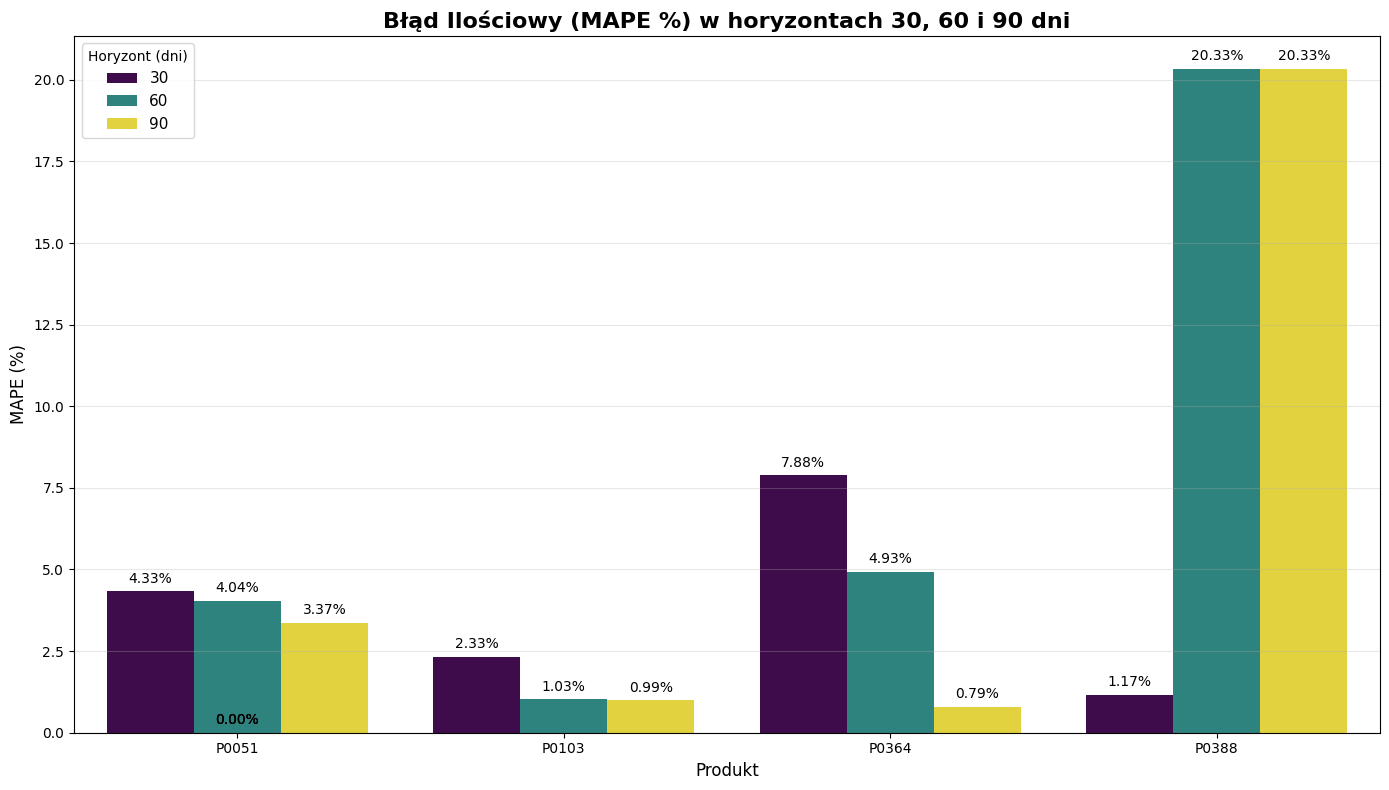

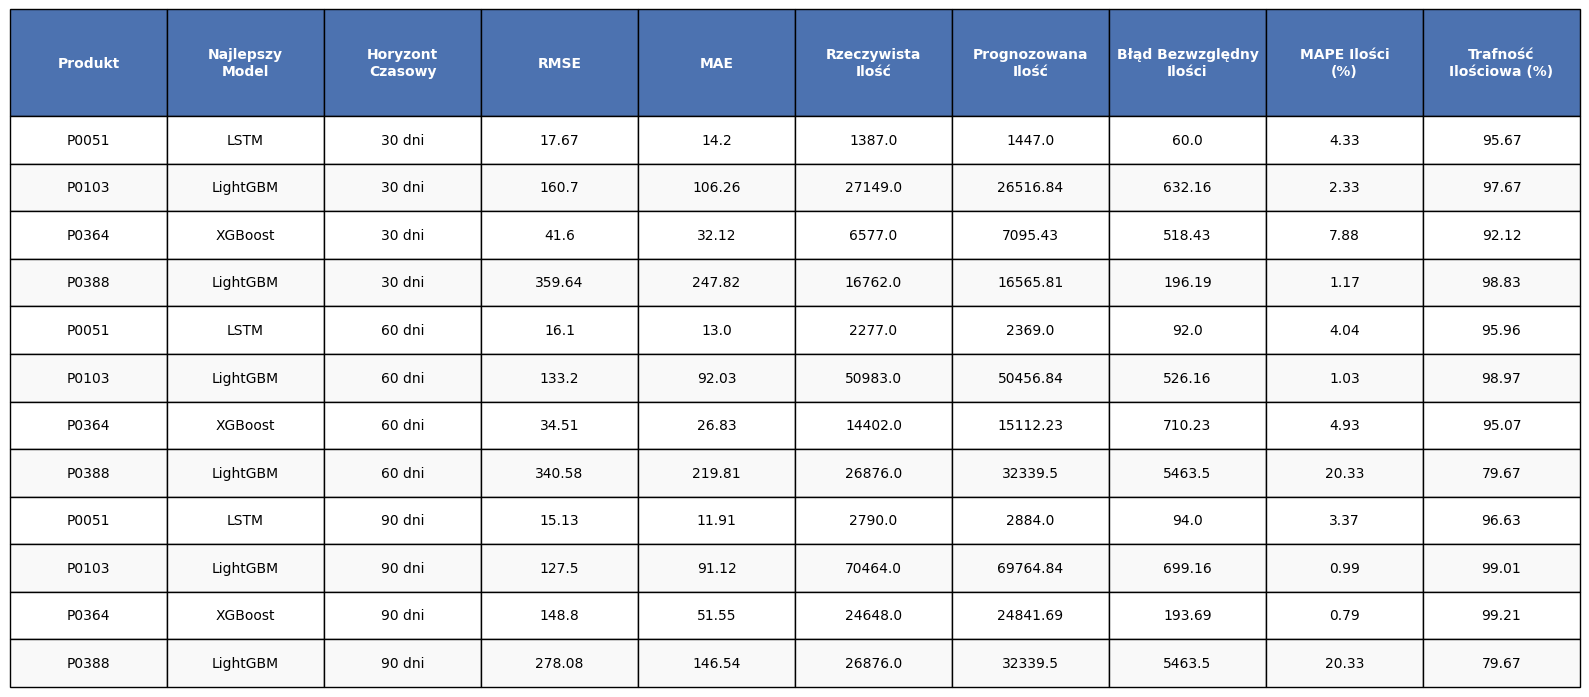

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Przygotowanie danych
data = {
    'Produkt': ['P0051', 'P0103', 'P0364', 'P0388', 'P0051', 'P0103', 'P0364', 'P0388', 'P0051', 'P0103', 'P0364', 'P0388'],
    'Najlepszy Model': ['LSTM', 'LightGBM', 'XGBoost', 'LightGBM', 'LSTM', 'LightGBM', 'XGBoost', 'LightGBM', 'LSTM', 'LightGBM', 'XGBoost', 'LightGBM'],
    'Horyzont Czasowy': [30, 30, 30, 30, 60, 60, 60, 60, 90, 90, 90, 90],
    'RMSE': [17.665409, 160.695272, 41.596267, 359.640634, 16.096583, 133.198293, 34.509631, 340.576809, 15.128340, 127.495626, 148.798951, 278.079800],
    'MAE': [14.200000, 106.261333, 32.122014, 247.821195, 13.000000, 92.030667, 26.834356, 219.814828, 11.911111, 91.120444, 51.554094, 146.543219],
    'Rzeczywista Ilość': [1387.0, 27149.0, 6577.0, 16762.0, 2277.0, 50983.0, 14402.0, 26876.0, 2790.0, 70464.0, 24648.0, 26876.0],
    'Prognozowana Ilość': [1447.0, 26516.84, 7095.426729, 16565.811516, 2369.0, 50456.84, 15112.234551, 32339.499006, 2884.0, 69764.84, 24841.694299, 32339.499006],
    'Błąd Bezwzględny Ilości': [60.0, 632.16, 518.426729, 196.188484, 92.0, 526.16, 710.234551, 5463.499006, 94.0, 699.16, 193.694299, 5463.499006],
    'MAPE Ilości (%)': [4.325883, 2.328484, 7.882419, 1.170436, 4.040404, 1.032030, 4.931499, 20.328542, 3.369176, 0.992223, 0.785842, 20.328542],
    'Trafność Ilościowa (%)': [95.674117, 97.671516, 92.117581, 98.829564, 95.959596, 98.967970, 95.068501, 79.671458, 96.630824, 99.007777, 99.214158, 79.671458]
}

df_results = pd.DataFrame(data)

# Zaokrąglenie do 2 miejsc po przecinku (do wykresu)
numeric_cols = ['RMSE', 'MAE', 'Rzeczywista Ilość', 'Prognozowana Ilość', 'Błąd Bezwzględny Ilości', 'MAPE Ilości (%)', 'Trafność Ilościowa (%)']
df_rounded = df_results.copy()
df_rounded[numeric_cols] = df_rounded[numeric_cols].round(2)

# =========================================================
# Canvas 1: Wykres
# =========================================================
fig1, ax1 = plt.subplots(figsize=(14, 8))
sns.barplot(data=df_rounded, x='Produkt', y='MAPE Ilości (%)', hue='Horyzont Czasowy', palette='viridis', ax=ax1)

ax1.set_title('Błąd Ilościowy (MAPE %) w horyzontach 30, 60 i 90 dni', fontsize=16, fontweight='bold')
ax1.set_ylabel('MAPE (%)', fontsize=12)
ax1.set_xlabel('Produkt', fontsize=12)

# Dodanie wartości liczbowych nad słupkami
for p in ax1.patches:
    height = p.get_height()
    if pd.notnull(height):
        ax1.annotate(f"{height:.2f}%", 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', fontsize=10, xytext=(0, 4), 
                     textcoords='offset points')

ax1.legend(title='Horyzont (dni)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
fig1.tight_layout()

# =========================================================
# Canvas 2: Graficzna Tabela z dostosowanym nagłówkiem
# =========================================================
df_display = df_rounded.copy()
df_display['Horyzont Czasowy'] = df_display['Horyzont Czasowy'].astype(str) + ' dni'

# Dodanie znaków nowej linii w nazwach kolumn, żeby lepiej się mieściły
df_display.columns = [
    'Produkt', 'Najlepszy\nModel', 'Horyzont\nCzasowy', 'RMSE', 'MAE',
    'Rzeczywista\nIlość', 'Prognozowana\nIlość', 'Błąd Bezwzględny\nIlości',
    'MAPE Ilości\n(%)', 'Trafność\nIlościowa (%)'
]

fig2, ax2 = plt.subplots(figsize=(16, 7))
ax2.axis('tight')
ax2.axis('off')

# Tworzenie graficznej tabeli bez sztucznego 'bbox', aby móc sterować wysokością
table = ax2.table(cellText=df_display.values, 
                  colLabels=df_display.columns, 
                  cellLoc='center', 
                  loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)

# Ręczne sterowanie wysokością komórek i stylami
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # Zwiększona wysokość pierwszego wiersza na nagłówki
        cell.set_height(0.18)
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4c72b0')
    elif row > 0:
        # Standardowa wysokość dla reszty wierszy z danymi
        cell.set_height(0.08)
        cell.set_facecolor('#f9f9f9' if row % 2 == 0 else 'white')

fig2.tight_layout()

# Wyświetlenie obu osobnych canvasów
plt.show()


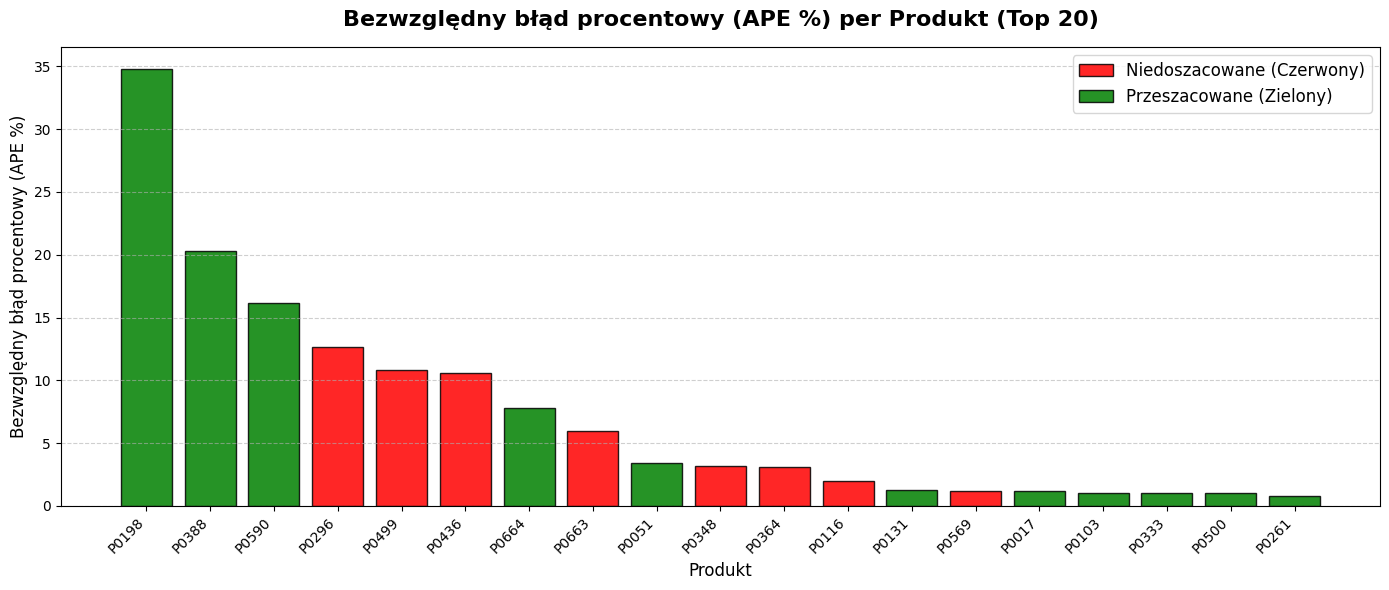

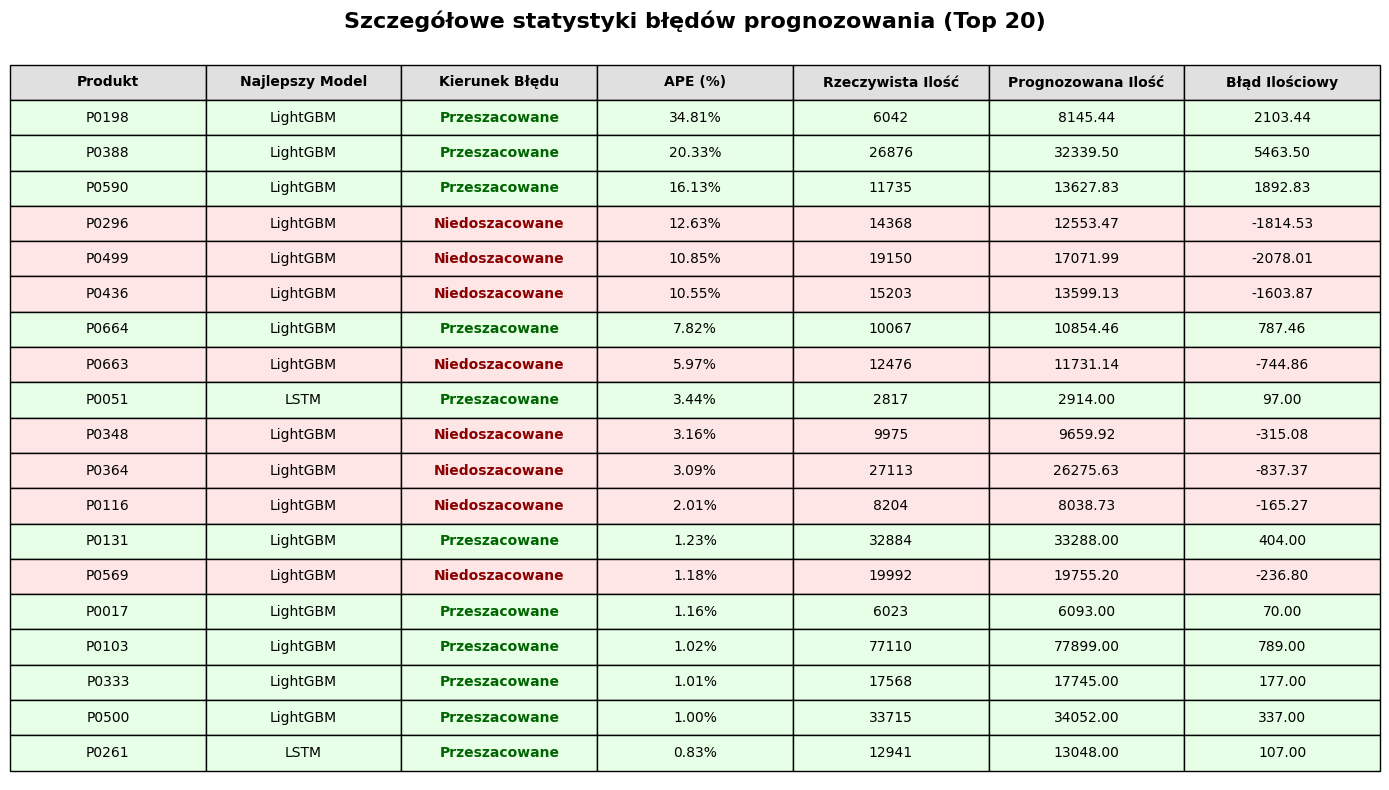

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
from matplotlib.patches import Patch

# 1. Wczytanie surowych danych
csv_data = """Index	Product	BestModel	BestModelStrategy	BestModelValRMSE	RMSE	MAE	QtyActual	QtyPredicted	SignedQtyError	BiasDirection	SignedPctError	AbsPctError	TrainTimeSec_LGBM	TrainTimeSec_XGB	TrainTimeSec_LSTM	TrainTimeSec_BestModel	TrainTimeSec_TotalAllModels
0	P0198	LightGBM	lgbm	10.539227	17.433543	13.290965	6042.0	8145.436304	2103.436304	Overpredicted	34.813577	34.813577	0.326401	0.080175	2.910080	0.326401	3.316657
1	P0388	LightGBM	fb_poly2_ridge	54.897915	257.451868	125.608473	26876.0	32339.499006	5463.499006	Overpredicted	20.328542	20.328542	0.083871	1.335274	2.505685	0.083871	3.924831
2	P0590	LightGBM	lgbm	16.910065	21.013220	13.974990	11735.0	13627.829869	1892.829869	Overpredicted	16.129782	16.129782	0.300491	0.064253	2.918524	0.300491	3.283269
3	P0296	LightGBM	lgbm	19.963154	42.104810	13.456375	14368.0	12553.465285	-1814.534715	Underpredicted	-12.629000	12.629000	0.364914	0.161506	3.082482	0.364914	3.608902
4	P0499	LightGBM	fb_poly2_ridge	40.942263	54.493741	19.954822	19150.0	17071.993996	-2078.006004	Underpredicted	-10.851206	10.851206	0.301405	0.044301	3.018802	0.301405	3.364508
5	P0436	LightGBM	fb_poly2_ridge	20.619321	26.582516	14.363012	15203.0	13599.125983	-1603.874017	Underpredicted	-10.549721	10.549721	0.293713	0.041762	3.224362	0.293713	3.559838
6	P0664	LightGBM	lgbm	30.063397	26.899724	12.566303	10067.0	10854.456516	787.456516	Overpredicted	7.822157	7.822157	0.274093	0.043519	3.818308	0.274093	4.135920
7	P0663	LightGBM	lgbm	18.697307	27.504935	15.522771	12476.0	11731.138506	-744.861494	Underpredicted	-5.970355	5.970355	0.262274	0.059759	3.462285	0.262274	3.784318
8	P0051	LSTM	lag1	58.058784	11.648726	7.156863	2817.0	2914.000000	97.000000	Overpredicted	3.443379	3.443379	0.288160	0.038290	3.134436	3.134436	3.460886
9	P0348	LightGBM	fb_poly2_ridge	22.801872	26.118780	13.904163	9975.0	9659.916102	-315.083898	Underpredicted	-3.158736	3.158736	0.073831	0.040249	3.423131	0.073831	3.537212
10	P0364	LightGBM	lgbm	80.155190	131.362852	35.623672	27113.0	26275.625403	-837.374597	Underpredicted	-3.088462	3.088462	0.360581	0.070622	3.678337	0.360581	4.109540
11	P0116	LightGBM	lgbm	8.158497	7.315502	2.101179	8204.0	8038.728066	-165.271934	Underpredicted	-2.014529	2.014529	0.326898	0.040674	3.291934	0.326898	3.659507
12	P0131	LightGBM	lag1	96.255817	49.845261	29.925000	32884.0	33288.000000	404.000000	Overpredicted	1.228561	1.228561	0.275609	0.038264	2.991837	0.275609	3.305710
13	P0569	LightGBM	fb_poly2_ridge	36.522651	27.196484	16.788575	19992.0	19755.198793	-236.801207	Underpredicted	-1.184480	1.184480	0.302268	0.040134	2.983809	0.302268	3.326211
14	P0017	LightGBM	lag1	18.988245	14.824810	7.550000	6023.0	6093.000000	70.000000	Overpredicted	1.162212	1.162212	0.378467	0.189355	2.941354	0.378467	3.509175
15	P0103	LightGBM	lag1	152.031154	124.955267	65.468750	77110.0	77899.000000	789.000000	Overpredicted	1.023214	1.023214	0.279926	0.052253	3.668312	0.279926	4.000491
16	P0333	LightGBM	lag1	28.306054	27.563223	15.218750	17568.0	17745.000000	177.000000	Overpredicted	1.007514	1.007514	0.379790	0.038799	3.214128	0.379790	3.632717
17	P0500	LightGBM	lag1	42.405500	80.722170	47.293750	33715.0	34052.000000	337.000000	Overpredicted	0.999555	0.999555	0.335784	0.048854	2.997310	0.335784	3.381948
18	P0261	LSTM	lag1	54.505492	78.826980	21.810458	12941.0	13048.000000	107.000000	Overpredicted	0.826829	0.826829	0.363393	0.039418	3.476224	3.476224	3.879036"""

df = pd.read_csv(io.StringIO(csv_data), sep='\t', index_col='Index')

# 2. Tłumaczenie nazw kolumn i wartości na język polski
kolumny_pl = {
    'Product': 'Produkt',
    'BestModel': 'Najlepszy Model',
    'QtyActual': 'Rzeczywista Ilość',
    'QtyPredicted': 'Prognozowana Ilość',
    'SignedQtyError': 'Błąd Ilościowy',
    'BiasDirection': 'Kierunek Błędu',
    'AbsPctError': 'APE (%)'
}
df = df.rename(columns=kolumny_pl)

df['Kierunek Błędu'] = df['Kierunek Błędu'].map({
    'Underpredicted': 'Niedoszacowane',
    'Overpredicted': 'Przeszacowane'
})

# Wybór Top 20
df_top = df.nlargest(20, 'APE (%)')

# ==========================================
# 3. WIZUALIZACJA: WYKRES SŁUPKOWY
# ==========================================
plt.figure(figsize=(14, 6))

colors = ['red' if kierunek == 'Niedoszacowane' else 'green' for kierunek in df_top['Kierunek Błędu']]
plt.bar(df_top['Produkt'], df_top['APE (%)'], color=colors, edgecolor='black', alpha=0.85)

legend_elements = [
    Patch(facecolor='red', edgecolor='black', alpha=0.85, label='Niedoszacowane (Czerwony)'),
    Patch(facecolor='green', edgecolor='black', alpha=0.85, label='Przeszacowane (Zielony)')
]
plt.legend(handles=legend_elements, fontsize=12)

plt.title('Bezwzględny błąd procentowy (APE %) per Produkt (Top 20)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Produkt', fontsize=12)
plt.ylabel('Bezwzględny błąd procentowy (APE %)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 4. WIZUALIZACJA: TABELA Z MATPLOTLIB
# ==========================================
kolumny_do_tabeli = [
    'Produkt', 'Najlepszy Model', 'Kierunek Błędu', 
    'APE (%)', 'Rzeczywista Ilość', 
    'Prognozowana Ilość', 'Błąd Ilościowy'
]

# Przygotowanie kopii do wygodnego formatowania wartości tekstowych
df_table = df_top[kolumny_do_tabeli].copy()
df_table['MAPE (%)'] = df_table['MAPE (%)'].apply(lambda x: f"{x:.2f}%")
df_table['Rzeczywista Ilość'] = df_table['Rzeczywista Ilość'].apply(lambda x: f"{x:.0f}")
df_table['Prognozowana Ilość'] = df_table['Prognozowana Ilość'].apply(lambda x: f"{x:.2f}")
df_table['Błąd Ilościowy'] = df_table['Błąd Ilościowy'].apply(lambda x: f"{x:.2f}")

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.axis('tight')

# Rysowanie tabeli
table = ax.table(cellText=df_table.values,
                 colLabels=df_table.columns,
                 cellLoc='center',
                 loc='center')

# Podstawowe formatowanie tabeli
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8) # Regulacja wysokości wierszy

direction_col_idx = list(df_table.columns).index('Kierunek Błędu')

# Iteracja po wszystkich komórkach w tabeli aby nałożyć kolory
for (row, col), cell in table.get_celld().items():
    # Formatowanie nagłówka (wiersz 0)
    if row == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#e0e0e0')
    else:
        # Odczytujemy kierunek błędu z danych w odpowiednim wierszu (row-1, bo dane są bez nagłówka)
        direction = df_table.iloc[row - 1, direction_col_idx]
        
        # Ustawiamy tło dla całego wiersza
        if direction == 'Niedoszacowane':
            cell.set_facecolor('#ffe6e6')  # Lekki czerwony
        elif direction == 'Przeszacowane':
            cell.set_facecolor('#e6ffe6')  # Lekki zielony
            
        # Zmiana samego tekstu w kolumnie "Kierunek Błędu" dla lepszej czytelności
        if col == direction_col_idx:
            cell.set_text_props(weight='bold')
            if direction == 'Niedoszacowane':
                cell.set_text_props(color='darkred')
            elif direction == 'Przeszacowane':
                cell.set_text_props(color='darkgreen')

plt.title('Szczegółowe statystyki błędów prognozowania (Top 20)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
